In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import solver
import sde
import gaussians

torch.manual_seed(42)

In [2]:
# SDE Setup
beta_min = 0.1
beta_max = 20
sde = sde.LinearVariancePreservingSDE(beta_min, beta_max)

In [3]:
# Gaussian & score setup
gaussian1 = gaussians.Gaussian(
    mu=0,
    sigma=1,
    weight=1/8
)
gaussian2 = gaussians.Gaussian(
    mu=-5,
    sigma=1,
    weight=3/8
)

gaussian3 = gaussians.Gaussian(
    mu=15,
    sigma=1,
    weight=1/2
)

multi_gaussian = gaussians.MultiGaussian((gaussian1, gaussian2, gaussian3), sde)
score_func = multi_gaussian.get_score_function()

# Create reverse sde based on score function
reverse_sde = sde.get_reverse_sde(score_func)

In [4]:
# Baseline PDF
interval = torch.linspace(-10, 20, 10000).reshape((10000, 1))
verification = multi_gaussian(interval)

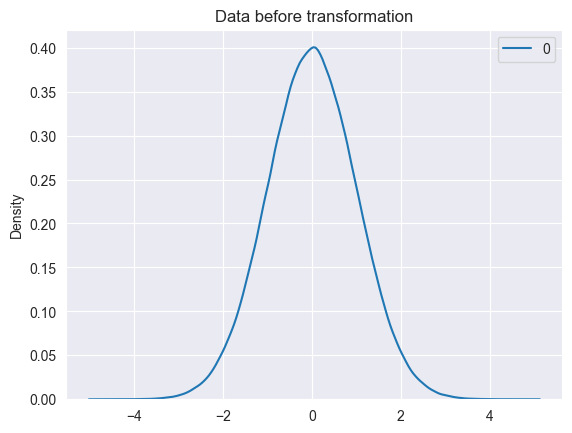

In [12]:
# Sampling setup
n_samples = 1000000
mu, sigma = 0, 1

mu, sigma = torch.full((n_samples,), mu), torch.full((n_samples,), sigma)
x_start = torch.randn((n_samples, 1))

# Plot initial data
plt.figure()
sns.kdeplot(x_start)
plt.title("Data before transformation")

In [6]:
# Euler Marayuma setup
multi_gaussian.reset_nfe()

n_steps = 1000
discretisation = torch.linspace(1, 0, n_steps)
em_solver = solver.EulerMarayumaSolver(reverse_sde, discretisation)

x_em = em_solver.solve(x_start.clone())

Text(0.5, 1.0, 'EM solver transforming to a multimodal Gaussian')

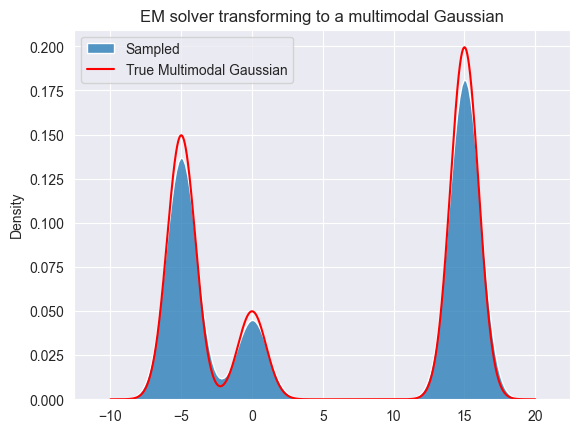

In [7]:
# Euler Marayuma Plots
plt.figure()
sns.kdeplot(x_em, label="Sampled", multiple="stack")
plt.plot(interval, verification, c="r", label="True Multimodal Gaussian")
plt.legend()
plt.title("EM solver transforming to a multimodal Gaussian")

In [8]:
# Euler Marayuma Evaluation
nfe_em_per_sample = multi_gaussian.nfe / n_samples

print(f"NFE per sample for Euler-Marayuma sampler: {nfe_em_per_sample}")

NFE per sample for Euler-Marayuma sampler: 999.0


In [9]:
# PI solver setup
multi_gaussian.reset_nfe()

pi_solver = solver.PISolver(
    reverse_sde,
    ki=0.101, 
    kp=0.09, 
    tau=0.1, 
    alpha=0.8, 
    h_start=0.001, 
    max_decrease=0.7, 
    max_increase=1.3
)

x_pi = pi_solver.solve(x_start.clone())

tensor(9.8982e-05)
154


Text(0.5, 1.0, 'PI adaptive solver transforming to a multimodal Gaussian')

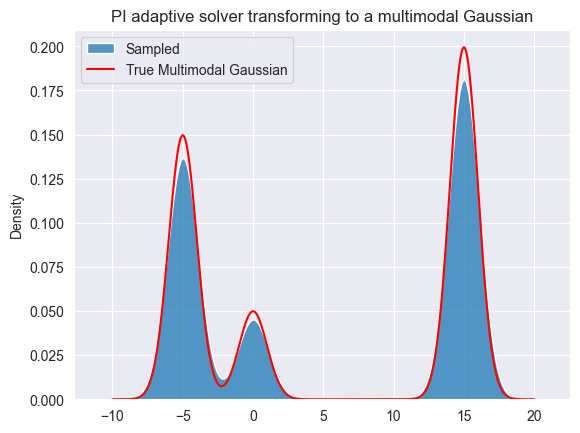

In [10]:
# PI Plots
plt.figure()
sns.kdeplot(x_pi, label="Sampled", multiple="stack")
plt.plot(interval, verification, c="r", label="True Multimodal Gaussian")
plt.legend()
plt.title("PI adaptive solver transforming to a multimodal Gaussian")

In [11]:
# PI Evaluation
nfe_pi_per_sample = multi_gaussian.nfe / n_samples

print(f"NFE per sample for PI sampler: {nfe_pi_per_sample}")

NFE per sample for Euler-Marayuma sampler: 209.896692
